In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
import os

import sys; sys.path.append('../../src/training-on-CM2.6')

from helpers.plot_helpers import default_rcParams

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

In [2]:
path_HR = '/scratch/pp2681/mom6/Neverworld2/simulations/R32/'
ds_HR = xr.open_mfdataset(path_HR+'longmean_*.nc', decode_times=False)
ds_HR_snapshots = xr.open_mfdataset(path_HR+'snapshots_*.nc', decode_times=False)

In [3]:
# p5
# path_LR_WENO = '/scratch/pp2681/mom6/Neverworld2/simulations/R2-WENO/WENO7/output/'
# ds_LR_WENO = xr.open_dataset(path_LR_WENO+'longmean_00029050.nc', decode_times=False)
# ds_LR_WENO_snapshots = xr.open_mfdataset(path_LR_WENO+'snapshots_00029000.nc', decode_times=False)
# os_LR_WENO = xr.open_dataset(path_LR_WENO+'ocean.stats.nc', decode_times=False)

#p3
path_LR_stable = '/scratch/pp2681/mom6/Neverworld2/simulations/R3-long/bare-stable/output/'
ds_LR_stable = xr.open_dataset(path_LR_stable+'longmean_00029050.nc', decode_times=False)
ds_LR_stable_snapshots = xr.open_mfdataset(path_LR_stable+'snapshots_00029010.nc', decode_times=False)
os_LR_stable = xr.open_dataset(path_LR_stable+'ocean.stats.nc', decode_times=False)

In [16]:
#exp_list = ['c1p0', 'c2p0', 'c2p5', 'GM200','GM800','MEKE']
exp_list = ['c3p5']

In [17]:
os_dic = {}
ds_mean_dic = {}
ds_snapshots_dic = {}

for exp in exp_list:
    if exp[0] == 'c':
        #path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/ANN_' + exp
        path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R3/ANN_' + exp + '/output/'
    else:
        path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R3/ANN_' + exp
        #path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/' + exp
    print(path)
    try: 
        os_dic[exp] = xr.open_dataset(path+'/ocean.stats.nc', decode_times=False)
        #ds_mean_dic[exp] = xr.open_dataset(path+'/longmean_00050050.nc', decode_times=False)
        ds_mean_dic[exp] = xr.open_dataset(path+'/longmean_00039050.nc', decode_times=False)
        #ds_snapshots_dic[exp] = xr.open_dataset(path+'/snapshots_00050010.nc', decode_times=False)
    except:
        try:
            os_dic[exp] = xr.open_dataset(path+'/output/ocean.stats.nc', decode_times=False)
            ds_mean_dic[exp] = xr.open_dataset(path+'/output/longmean_00050050.nc', decode_times=False)
            ds_snapshots_dic[exp] = xr.open_dataset(path+'/output/snapshots_00050010.nc', decode_times=False)
        except:
            print(f"Could not open ocean.stats.nc for experiment {exp}")
            
        

/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R3/ANN_c3p5/output/


In [ ]:
ds_HR['e_mean'] = ds_HR['e'].mean('time').compute()


In [18]:
ds_LR_stable['e_mean'] = ds_LR_stable['e'].mean('time').compute()
#ds_LR_WENO['e_mean'] = ds_LR_WENO['e'].mean('time').compute()

for exp in exp_list:
    ds_mean_dic[exp]['e_mean'] = ds_mean_dic[exp]['e'].mean('time').compute()

In [14]:
factor = len(ds_HR.xh) // len(ds_LR_stable.xh)
#HR_e_mean = ds_HR.e_mean.coarsen({'xh': factor, 'yh': factor}).mean().interp(xh=ds_LR_WENO.xh, yh=ds_LR_WENO.yh)#.mean(dim='time')
HR_e_mean = ds_HR.e_mean.coarsen({'xh': factor, 'yh': factor}).mean().interp(xh=ds_LR_stable.xh, yh=ds_LR_stable.yh)#.mean(dim='time')

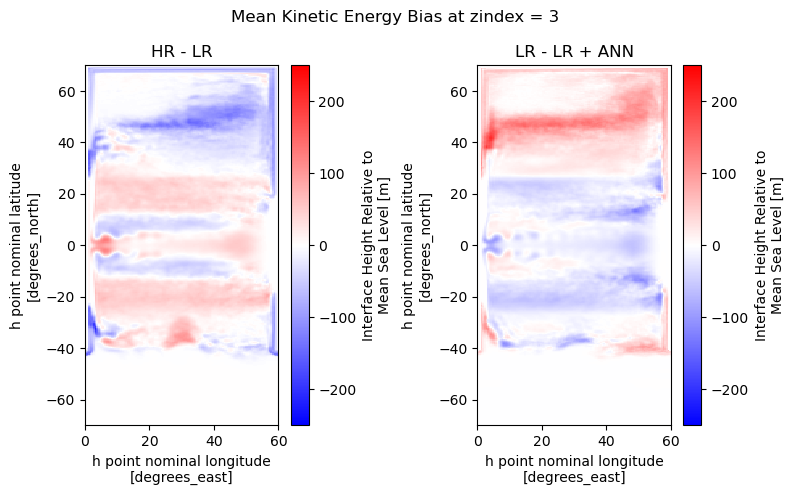

In [10]:
plt.figure(figsize=(8,5))

zindex = 3

plt.subplot(1,2,1)
(HR_e_mean - ds_LR_WENO['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(ds_LR_WENO['e_mean'] - ds_mean_dic['c2p0']['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.suptitle(f'Mean Kinetic Energy Bias at zindex = {zindex}')
plt.tight_layout()

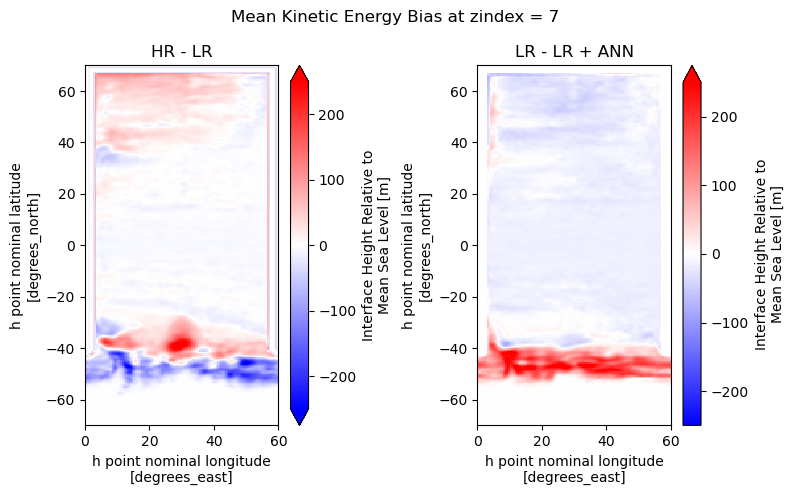

In [9]:
plt.figure(figsize=(8,5))

zindex = 7

plt.subplot(1,2,1)
(HR_e_mean - ds_LR_WENO['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(ds_LR_WENO['e_mean'] - ds_mean_dic['c2p0']['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.suptitle(f'Mean Kinetic Energy Bias at zindex = {zindex}')
plt.tight_layout()

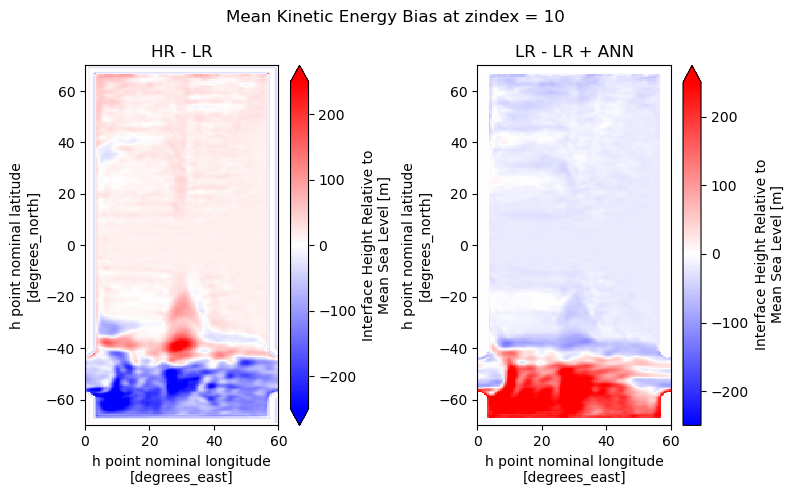

In [11]:
plt.figure(figsize=(8,5))

zindex = 10

plt.subplot(1,2,1)
(HR_e_mean - ds_LR_WENO['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(ds_LR_WENO['e_mean'] - ds_mean_dic['c2p0']['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.suptitle(f'Mean Kinetic Energy Bias at zindex = {zindex}')
plt.tight_layout()

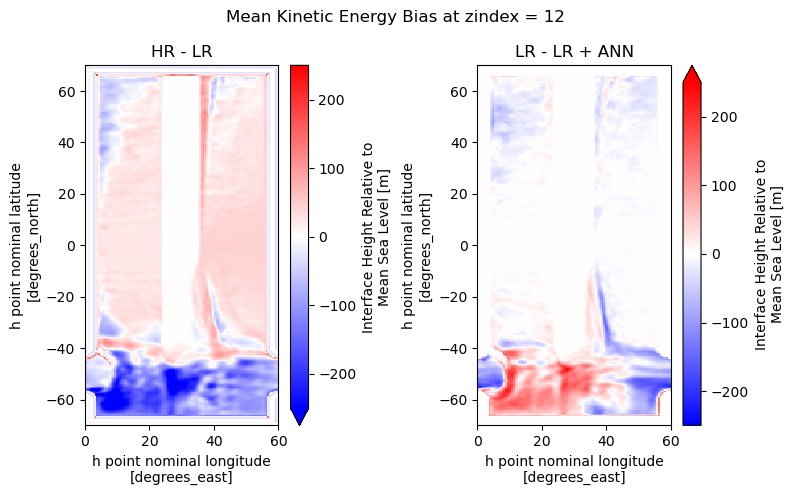

In [12]:
plt.figure(figsize=(8,5))

zindex = 12

plt.subplot(1,2,1)
(HR_e_mean - ds_LR_WENO['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(ds_LR_WENO['e_mean'] - ds_mean_dic['c2p0']['e_mean']).isel(zi = zindex).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.suptitle(f'Mean Kinetic Energy Bias at zindex = {zindex}')
plt.tight_layout()

Text(0.5, 0.98, 'Mean Kinetic Energy Bias Averaged Over All Heights')

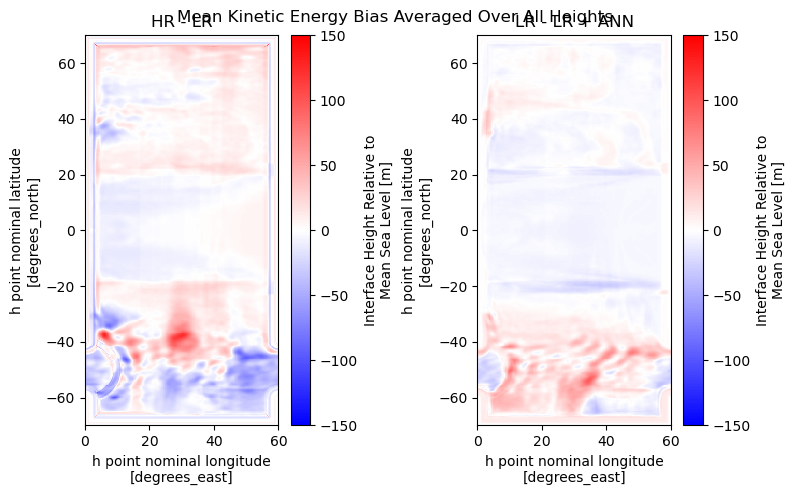

In [20]:
plt.figure(figsize=(8,5))


plt.subplot(1,2,1)
(HR_e_mean - ds_LR_stable['e_mean']).mean('zi').plot(vmin=-150, vmax=150, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(ds_LR_stable['e_mean'] - ds_mean_dic['c3p5']['e_mean']).mean('zi').plot(vmin=-150, vmax=150, cmap='bwr')
plt.title('LR - LR + ANN')

plt.tight_layout()
plt.suptitle('Mean Kinetic Energy Bias Averaged Over All Heights')